# Desafio Final — Análise de Dados de Energia com API Pública

**Integrantes:** Aline Medri Marcolino - RM:569349 e Luis Fernado de Azevedo - RM:574167

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

#Fonte dos dados
API pública de Carga Verificada do ONS:

Portal: https://dados.ons.org.br/
Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada
Neste notebook será utilizada inicialmente a área SP — São Paulo, no período de 01/08/2025 a 07/08/2025.

##Bibliotecas

In [128]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [129]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


In [130]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [131]:
type(registros)

list

In [132]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga


##**DESAFIO 1 — Construção e inspeção do DataFrame**

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.


In [133]:
#Criando DataFrame e os registros
dados=pd.DataFrame(registros)
display(dados.head())

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [134]:
#Quantidade de linhas e colunas
print("Quantidade de linhas:", dados.shape[0])
print("Quantidadede colunas:", dados.shape[1])

Quantidade de linhas: 336
Quantidadede colunas: 11


In [135]:
#Nomes dos atributos
print("Atributos:")
print(dados.columns.tolist())

Atributos:
['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']


In [136]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [137]:
display(dados.describe(include="all"))

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336,336,336,336,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
unique,1,7,7,336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-07T19:00:00.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,336,48,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,NaN,NaN,NaN,NaN,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,NaN,NaN,NaN,NaN,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,NaN,NaN,NaN,NaN,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,NaN,NaN,NaN,NaN,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,NaN,NaN,NaN,NaN,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0


In [138]:
COLUNA_DATA_HORA = "din_atualizacao"
COLUNA_AREA ="cod_areacarga"
COLUNA_CARGA = "val_cargaglobal"

print("Data/hora:", COLUNA_DATA_HORA)
print("Área de carga:", COLUNA_AREA)
print("Valor de carga:", COLUNA_CARGA)

Data/hora: din_atualizacao
Área de carga: cod_areacarga
Valor de carga: val_cargaglobal


##**Desafio 2- Organização dos dados**

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [139]:
#1- Renomear os atributos
renomear = {
    "cod_areacarga":"Área",
    "dat_referencia":"Data_Hora",
    "val_cargaglobal":"Carga"
}
if renomear:
    dados = dados.rename(columns=renomear)
print(dados.columns.tolist())

['Área', 'din_atualizacao', 'Data_Hora', 'din_referenciautc', 'Carga', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']


In [140]:
#DataFrame dos atributos necessários
df_carga = dados[["Área", "Data_Hora", "Carga"]].copy()
print(df_carga.head())

  Área   Data_Hora      Carga
0   SP  2025-08-01  15913.618
1   SP  2025-08-01  15251.414
2   SP  2025-08-01  14606.733
3   SP  2025-08-01  14182.290
4   SP  2025-08-01  13838.488


In [141]:
ausentes = df_carga.isnull().sum()
print(ausentes.to_string())

Área         0
Data_Hora    0
Carga        0


In [142]:
# Verifique se a variável de carga está em formato numérico e como a data/hora está representada
df_carga["Data_Hora"] = pd.to_datetime(df_carga["Data_Hora"])
df_carga["Carga"] = pd.to_numeric(df_carga["Carga"], errors="coerce")
df_carga = df_carga.dropna(subset=["Área", "Data_Hora", "Carga"])
print(df_carga.dtypes)
print(df_carga.head())

Área                 object
Data_Hora    datetime64[ns]
Carga               float64
dtype: object
  Área  Data_Hora      Carga
0   SP 2025-08-01  15913.618
1   SP 2025-08-01  15251.414
2   SP 2025-08-01  14606.733
3   SP 2025-08-01  14182.290
4   SP 2025-08-01  13838.488


In [143]:
# Verificação final de ausentes e duplicados
print("Valores ausentes:")
display(df_carga.isna().sum())

print("\nRegistros duplicados:", df_carga.duplicated().sum())

Valores ausentes:


,0
Área,0
Data_Hora,0
Carga,0



Registros duplicados: 0


## **DESAFIO 3 — Indicadores da carga elétrica**
Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.



In [144]:
serie_carga = df_carga["Carga"].dropna()

serie_carga = pd.to_numeric(serie_carga, errors="coerce").dropna()

carga_minima = serie_carga.min()
carga_maxima = serie_carga.max()
carga_media = serie_carga.mean()
carga_mediana = serie_carga.median()

amplitude = carga_maxima - carga_minima

quantidade_total = len(serie_carga)

indicadores = pd.DataFrame({
    "Indicador": [
        "Carga mínima",
        "Carga máxima",
        "Carga média",
        "Mediana",
        "Amplitude",
        "Quantidade total de medições"
    ],
    "Valor": [
        carga_minima,
        carga_maxima,
        carga_media,
        carga_mediana,
        amplitude,
        quantidade_total
    ]
})

display(indicadores)

,Indicador,Valor
0,Carga mínima,12139.253000
1,Carga máxima,23185.312000
2,Carga média,17870.828981
3,Mediana,18199.128500
4,Amplitude,11046.059000
5,Quantidade total de medições,336.000000


**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

R: O valor máximo representa um aumento relevante em relação à média, mas os indicadores mostram que ele ainda está dentro de uma variação observada nos dados, não caracterizando necessariamente um comportamento muito fora do padrão.

## **DESAFIO 4 — Períodos de alta demanda**
Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.


In [145]:
#  Limiar
limiar_alta = 0.90 * carga_maxima

# DataFrame  do limiar
df_alta_demanda = df_carga[
   df_carga["Carga"] > limiar_alta
].copy()

# Conte os reistros
quantidade_alta = len(df_alta_demanda)

# Percentual
percentual_alta = quantidade_alta / quantidade_total * 100

print(f"Carga máxima: {carga_maxima:.2f}")
print(f"Limiar de 90%: {limiar_alta:.2f}")
print(f"Quantidade de registros de alta demanda: {quantidade_alta}")
print(f"Percentual: {percentual_alta:.2f}%")

display(df_alta_demanda.head())

Carga máxima: 23185.31
Limiar de 90%: 20866.78
Quantidade de registros de alta demanda: 50
Percentual: 14.88%


,Área,Data_Hora,Carga
35,SP,2025-08-01,21088.959
36,SP,2025-08-01,22398.360
37,SP,2025-08-01,23185.312
38,SP,2025-08-01,22903.314
39,SP,2025-08-01,22358.701


In [146]:
#  Maior valor
maior_carga = df_carga["Carga"].max()

#  Data/hora do pico
idx_pico = df_carga["Carga"].idxmax()
registro_pico = df_carga.loc[idx_pico]

print("Maior valor de carga:", maior_carga)
print("Momento do pico:")

if COLUNA_DATA_HORA in registro_pico.index:
    print(registro_pico[["Data_Hora"]])
else:
    print("Data/hora não disponível.")

display(pd.DataFrame([registro_pico]))

Maior valor de carga: 23185.312
Momento do pico:
Data/hora não disponível.


,Área,Data_Hora,Carga
37,SP,2025-08-01,23185.312


**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

R:Como  85,12% das medições não estão nessa faixa de alta demanda, os períodos próximos ao pico são relativamente pontuais e não representam a maior parte do comportamento observado.

# **DESAFIO 5 — Segundo critério de análise**

### Critério escolhido pela equipe

Foi escolhido o critério:

**carga acima da média da série.**


O critério de 90% do máximo é mais restritivo, pois seleciona apenas registros muito próximos do maior valor observado. Já o critério de carga acima da média tende a selecionar uma parcela maior das observações, pois utiliza como referência o comportamento central da série.

In [147]:
#  Critério
limiar_media = carga_media

#  Novo DataFrame
df_acima_media = df_carga[
    df_carga["Carga"] > limiar_media
].copy()

#  Quantidade
quantidade_acima_media = len(df_acima_media)

#  Percentual
percentual_acima_media = quantidade_acima_media / quantidade_total * 100

print(f"Critério: carga > média ({limiar_media:.2f})")
print(f"Quantidade: {quantidade_acima_media}")
print(f"Percentual: {percentual_acima_media:.2f}%")

display(df_acima_media.head())

Critério: carga > média (17870.83)
Quantidade: 184
Percentual: 54.76%


,Área,Data_Hora,Carga
15,SP,2025-08-01,18096.023
16,SP,2025-08-01,18629.395
17,SP,2025-08-01,18825.176
18,SP,2025-08-01,19056.504
19,SP,2025-08-01,19427.822


In [148]:
# Comparação com alta demanda
comparacao_criterios = pd.DataFrame({
    "Critério": [
        "Carga > 90% do máximo",
        "Carga > média"
    ],
    "Quantidade": [
        quantidade_alta,
        quantidade_acima_media
    ],
    "Percentual": [
        percentual_alta,
        percentual_acima_media
    ]
})

display(comparacao_criterios)

,Critério,Quantidade,Percentual
0,Carga > 90% do máximo,50,14.880952
1,Carga > média,184,54.761905


##**DESAFIO 6 — Visualização**

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

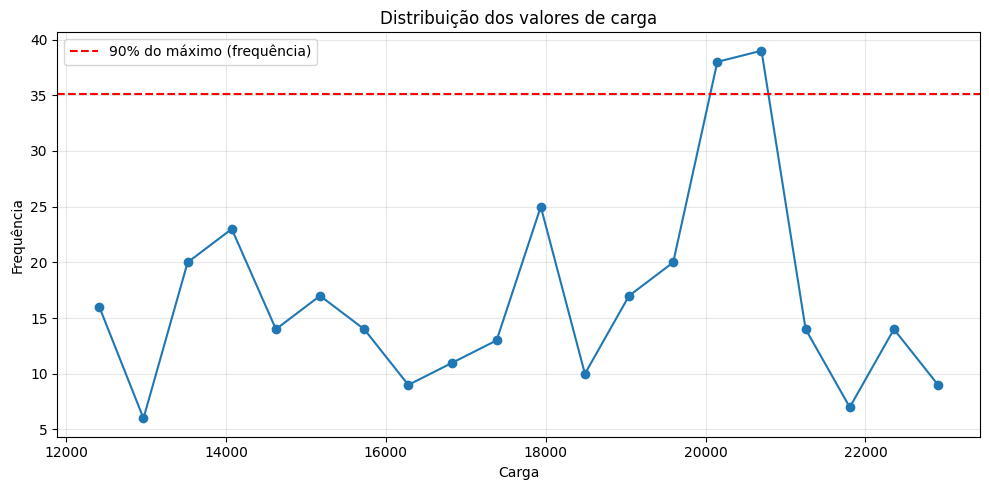

In [149]:
# Gráfico de linha — Distribuição dos valores de carga
frequencias, bordas = np.histogram(serie_carga, bins=20)
centros_bins = (bordas[:-1] + bordas[1:]) / 2
limiar_freq = 0.9 * frequencias.max()

plt.figure(figsize=(10, 5))
plt.plot(centros_bins, frequencias, marker="o", linewidth=1.5)
plt.axhline(limiar_freq, linestyle="--", color="red", label="90% do máximo (frequência)")
plt.title("Distribuição dos valores de carga")
plt.xlabel("Carga")
plt.ylabel("Frequência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretação do gráfico 1

A distribuição indica que as cargas se concentram principalmente em determinadas faixas, enquanto os valores próximos ao pico aparecem com menor frequência. Isso reforça que os períodos de alta demanda representam uma parcela menor das medições.

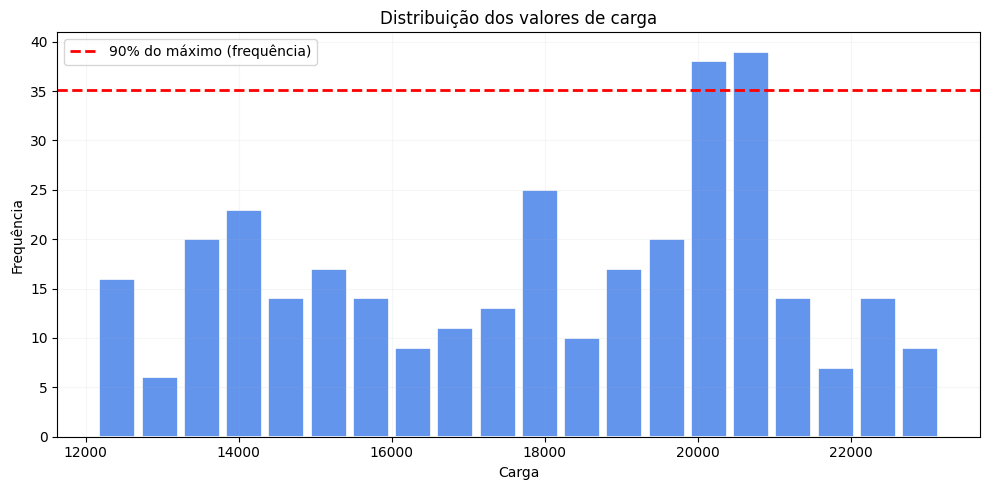

In [150]:
## Gráfico 2 — Distribuição da carga
frequencias, bordas = np.histogram(serie_carga, bins=20)
limiar_freq = 0.9 * frequencias.max()

plt.figure(figsize=(10, 5))
plt.hist(serie_carga, bins=20, color="CornflowerBlue", edgecolor="white",
          linewidth=1.2, rwidth=0.85)
plt.axhline(limiar_freq, linestyle="--", color="red", linewidth=2,
            label="90% do máximo (frequência)")
plt.title("Distribuição dos valores de carga")
plt.xlabel("Carga")
plt.ylabel("Frequência")
plt.legend()
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

### Interpretação do gráfico 2

O histograma mostra a concentração das medições de carga e permite visualizar a variação dos valores. Observa-se que os registros acima de 90% da carga máxima são menos frequentes, correspondendo a 14,88% das medições.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.



In [151]:
# Identificar o registro com a maior carga
registro_pico = df_carga.loc[df_carga["Carga"].idxmax()]
momento_pico = registro_pico["Data_Hora"]

resumo_resultados = {
    "regiao": df_carga["Área"].dropna().iloc[0]
               if not df_carga["Área"].dropna().empty
               else "Não informado",

    "periodo_inicio": df_carga["Data_Hora"].min(),
    "periodo_fim": df_carga["Data_Hora"].max(),
    "quantidade_registros": quantidade_total,
    "carga_minima": carga_minima,
    "carga_maxima": carga_maxima,
    "carga_media": carga_media,
    "mediana": carga_mediana,
    "amplitude": amplitude,
    "limiar_alta_demanda": limiar_alta,
    "quantidade_alta_demanda": quantidade_alta,
    "percentual_alta_demanda": percentual_alta,
    "momento_pico": momento_pico,
    "criterio_2": "Carga acima da média",
    "quantidade_criterio_2": quantidade_acima_media,
    "percentual_criterio_2": percentual_acima_media
}
print(resumo_resultados)

{'regiao': 'SP', 'periodo_inicio': Timestamp('2025-08-01 00:00:00'), 'periodo_fim': Timestamp('2025-08-07 00:00:00'), 'quantidade_registros': 336, 'carga_minima': 12139.253, 'carga_maxima': 23185.312, 'carga_media': np.float64(17870.828980654762), 'mediana': 18199.1285, 'amplitude': 11046.059000000001, 'limiar_alta_demanda': 20866.7808, 'quantidade_alta_demanda': 50, 'percentual_alta_demanda': 14.880952380952381, 'momento_pico': Timestamp('2025-08-01 00:00:00'), 'criterio_2': 'Carga acima da média', 'quantidade_criterio_2': 184, 'percentual_criterio_2': 54.761904761904766}


# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [152]:
!pip -q install -U google-genai

In [153]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [154]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [155]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

# Relatório Técnico de Análise de Carga — Setor Elétrico

**Região Analisada:** SP  
**Período:** 01/08/2025 00:00:00 a 07/08/2025 00:00:00  
**Elaborado por:** Analista de Dados do Setor Elétrico  

---

### 1. Caracterização do Conjunto Analisado
O conjunto de dados refere-se ao acompanhamento de carga na região de São Paulo (SP) durante o período de 7 dias (de 01 a 07 de agosto de 2025). O total de observações registradas no intervalo foi de **336 registros**.

---

### 2. Principais Indicadores
Com base na medição da carga no período, foram apurados os seguintes indicadores estáticos e descritivos:

* **Carga Mínima:** 12.139,25
* **Carga Máxima (Pico):** 23.185,31
* **Carga Média:** 17.870,83
* **Mediana:** 18.199,13
* **Amplitude Total:** 11.046,06
* **Momento de Pico:** 01/08/2025 às 00:00:00

*Observação Estatística:* A mediana (18.199,13) apresentou valor superior à carga média (17.870,83), indicando que a maior parte das medições se concentrou na metade superior da faixa de c

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?



1- Os indicadores foram utilizados corretamente?

R: Sim, os indicadores foram calculados corretamente e utilizados para analisar o comportamento da carga.

2- Há alguma afirmação que não pode ser confirmada pelos dados?

R:Os dados mostram os valores da carga e quando eles aconteceram, mas não explicam o motivo das variações. Por isso, não dá para dizer que o aumento ou a redução da carga aconteceu por causa da temperatura, do clima, do consumo ou do comportamento dos consumidores.

3- Houve interpretação exagerada ou causalidade não demonstrada?

R: Não. A equipe evitou dizer que existe uma causa específica para os aumentos da carga, pois isso não aparece nos dados. A análise ficou focada apenas no que os resultados mostram.

4-Que alterações a equipe realizou no texto?

R: A equipe revisou o relatório priorizando objetividade e transparência: simplificou a redação para dar mais destaque aos indicadores calculados, eliminou trechos que sugeriam explicações.